In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
# Load the dataset
df = pd.read_csv(r"E:\Pradhumn- DS\Datasets\Star Classification\6 class csv.csv")

In [ ]:
df.head()   

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M


In [ ]:
#no missing values present in the dataset
df.isnull().sum()

Temperature (K)           0
Luminosity(L/Lo)          0
Radius(R/Ro)              0
Absolute magnitude(Mv)    0
Star type                 0
Star color                0
Spectral Class            0
dtype: int64

In [28]:
#percentage of missing values in each column
missing_percent = (df.isnull().sum() / len(df)) * 100
print(missing_percent)

Temperature (K)           0.0
Luminosity(L/Lo)          0.0
Radius(R/Ro)              0.0
Absolute magnitude(Mv)    0.0
Star type                 0.0
Star color                0.0
Spectral Class            0.0
dtype: float64


In [ ]:
#checking for duplicates
df.duplicated().sum()

0

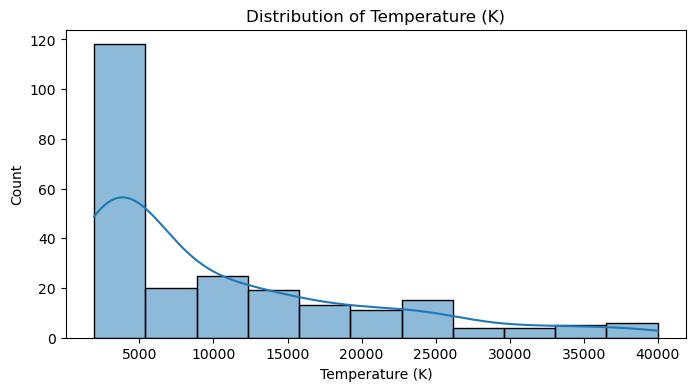

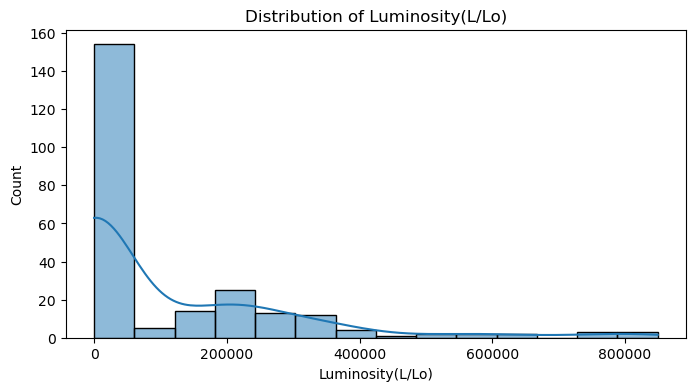

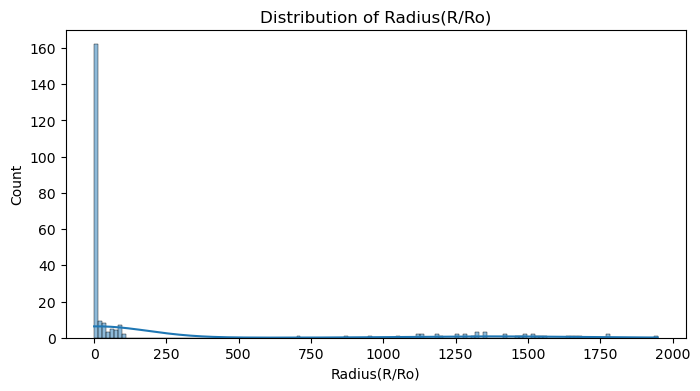

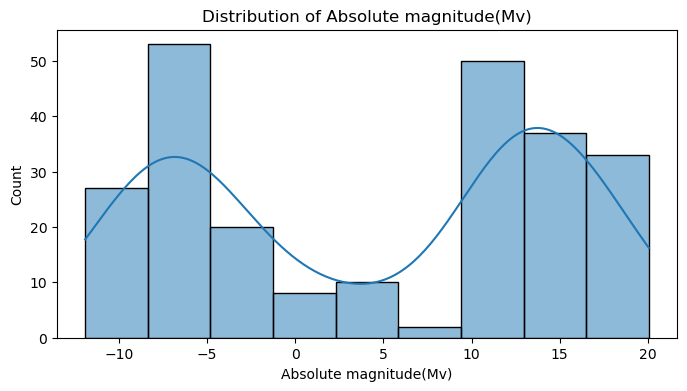

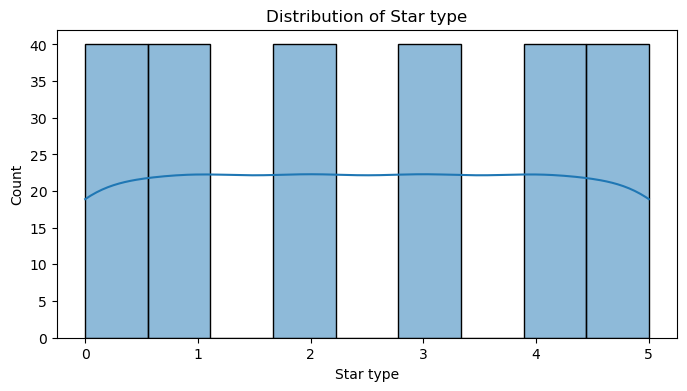

In [29]:
#checking for the distribution of numerical features
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

In [ ]:
#checking for skewness of numerical features
from scipy import stats
from scipy.stats import skew, kurtosis

for col in num_cols:
    
    skewness = skew(df[col].dropna())
    
    print(f"{col} Skewness: {skewness}")

Temperature (K) Skewness: 1.3132941596030199
Luminosity(L/Lo) Skewness: 2.0551209435208415
Radius(R/Ro) Skewness: 1.9346117254577848
Absolute magnitude(Mv) Skewness: -0.1207786427322443
Star type Skewness: 0.0


In [21]:
for col in num_cols:
    
    k = kurtosis(df[col].dropna())
    
    print(f"{col} Kurtosis: {k}")

Temperature (K) Kurtosis: 0.8342840793595045
Luminosity(L/Lo) Kurtosis: 4.347719820735566
Radius(R/Ro) Kurtosis: 2.0051033520992183
Absolute magnitude(Mv) Kurtosis: -1.6464870413542498
Star type Kurtosis: -1.2685714285714282


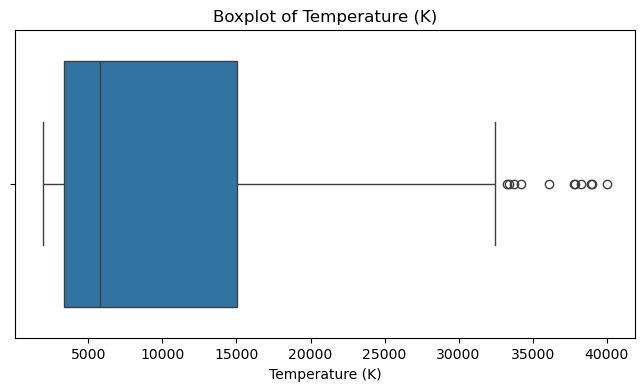

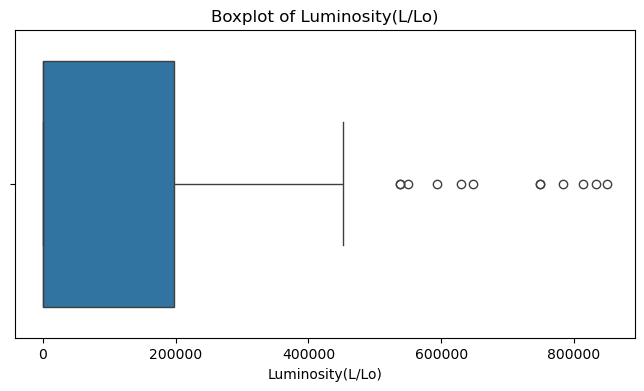

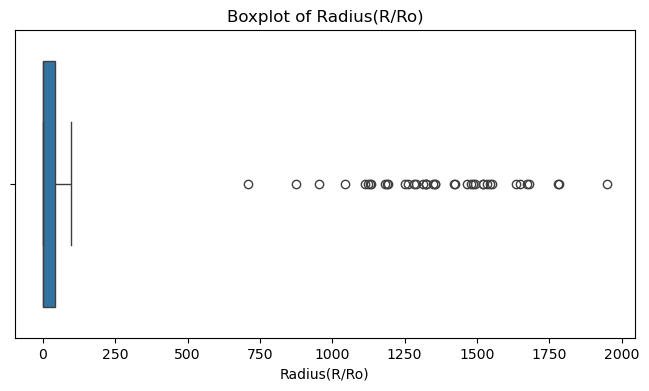

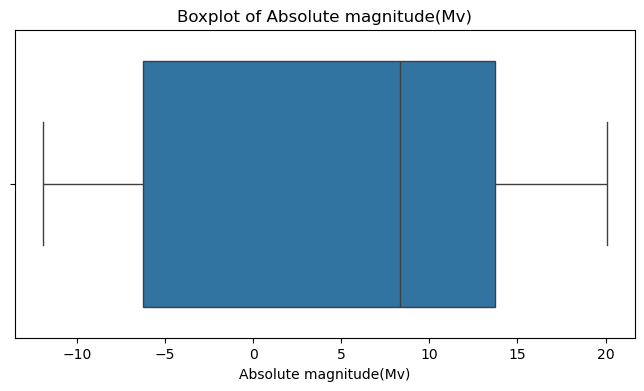

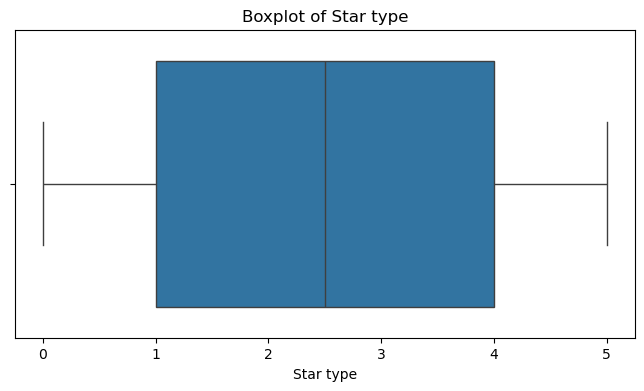

In [22]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

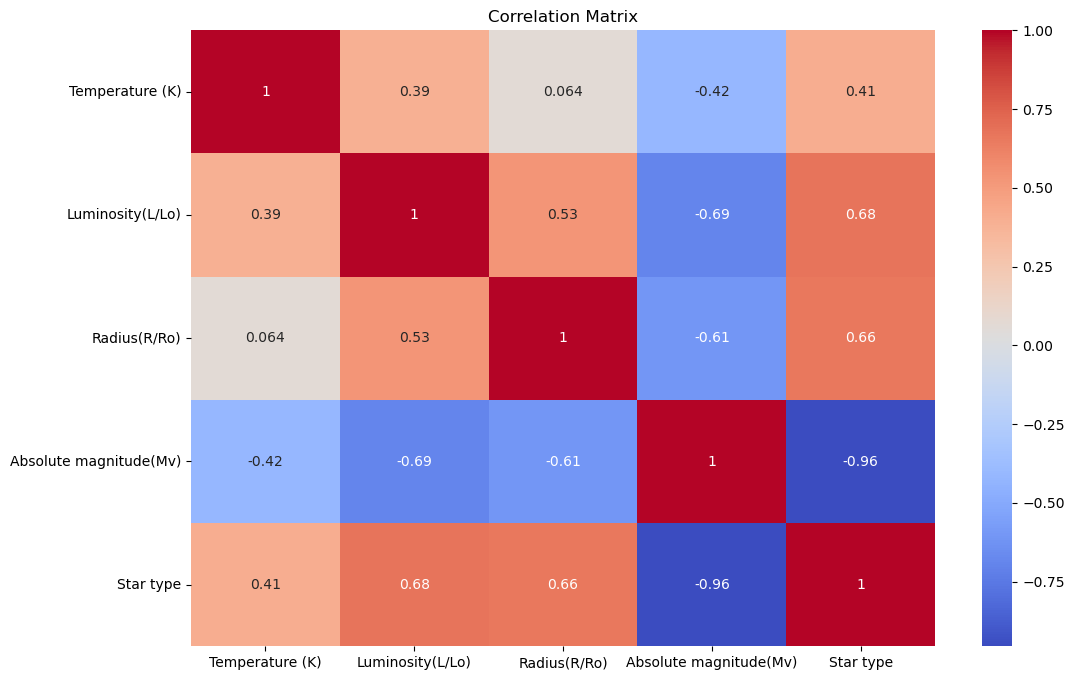

In [23]:
corr = df[num_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

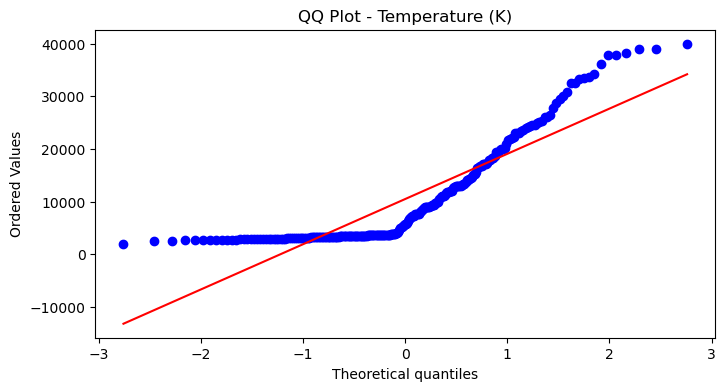

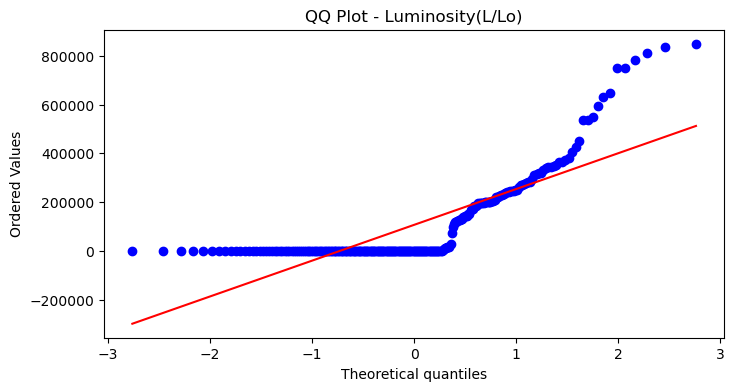

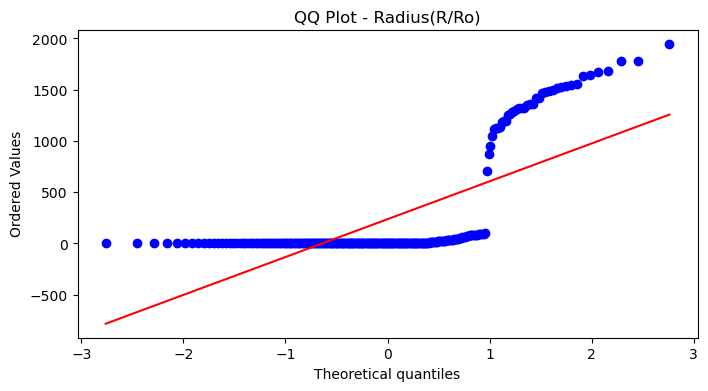

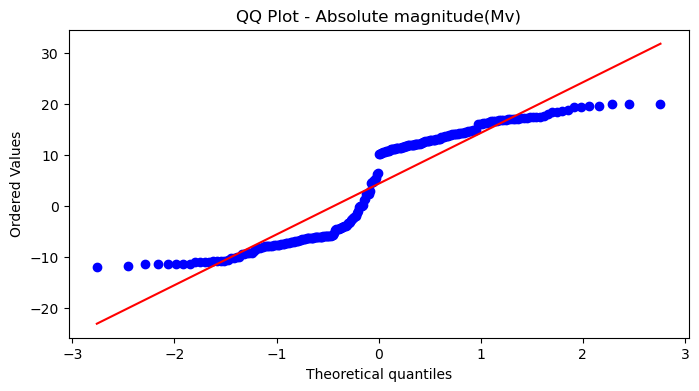

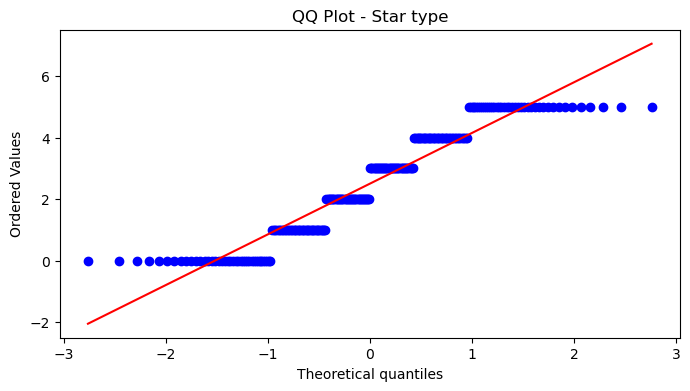

In [24]:
for col in num_cols:
    
    plt.figure(figsize=(8,4))
    
    stats.probplot(df[col].dropna(), dist="norm", plot=plt)
    
    plt.title(f"QQ Plot - {col}")
    
    plt.show()

In [25]:
for col in num_cols:
    
    stat, p = stats.shapiro(df[col].dropna())
    
    print(f"{col}")
    print("P-value:", p)
    
    if p > 0.05:
        print("Data looks Normal")
    else:
        print("Data is NOT Normal")
    
    print()

Temperature (K)
P-value: 3.967419649652892e-17
Data is NOT Normal

Luminosity(L/Lo)
P-value: 1.168692008202427e-21
Data is NOT Normal

Radius(R/Ro)
P-value: 1.655239147135894e-25
Data is NOT Normal

Absolute magnitude(Mv)
P-value: 1.788624291156376e-13
Data is NOT Normal

Star type
P-value: 3.9392721309130856e-11
Data is NOT Normal

